# **Part II - Bike Sharing System Usage 2019, Feb**
**by Abduaziz**

# **🚲Investigation Overview**

<p align="center">
    <img src="https://upload.wikimedia.org/wikipedia/en/9/95/Bay_Wheels_logo.png">
</p>

Bay Wheels is a regional public bicycle sharing system in California's San Francisco Bay Area. It is operated by Motivate in a partnership with the Metropolitan Transportation Commission and the Bay Area Air Quality Management District.Bay Wheels is 'the first regional and large-scale bicycle sharing system deployed in California and on the West Coast of the United States. It was established as Bay Area Bike Share in August 2013. As of January 2018, the Bay Wheels system had over 2,600 bicycles in 262 stations across San Francisco, East Bay and San Jose.

# **Dataset Overview**

The dataset used for this exploratory analysis consists of individual trip data. There were 16 columns and after cleaning process they are 12. There are 16 types of columns. 
Dataset consists:
- Information about trip (duration ...):
- Information about stations (its cords, name and id)
- Users data (type of their, age,gender ...)

In [1]:
# import all packages and set plots to be embedded inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

%matplotlib inline

# suppress warnings from final output
import warnings
warnings.simplefilter("ignore")

In [2]:
# load in the dataset into a pandas dataframe
df = pd.read_csv("fordgobike_clean.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 174377 entries, 0 to 174376
Data columns (total 13 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Unnamed: 0               174377 non-null  int64  
 1   duration_sec             174377 non-null  int64  
 2   start_time               174377 non-null  object 
 3   end_time                 174377 non-null  object 
 4   start_station_latitude   174377 non-null  float64
 5   start_station_longitude  174377 non-null  float64
 6   user_type                174377 non-null  object 
 7   member_gender            174377 non-null  object 
 8   member_age               174377 non-null  int64  
 9   duration_min             174377 non-null  int64  
 10  start_hour_of_day        174377 non-null  int64  
 11  start_day_of_week        174377 non-null  object 
 12  start_month              174377 non-null  object 
dtypes: float64(2), int64(5), object(6)
memory usage: 13.3+ MB


In [3]:
# Change figure size
sb.set(rc={'figure.figsize':(14.7,8.27)})

### **✅ Hourly Usage Of Bikes vary by weekdays on Subscribers & Customers**
These heat maps show very different patterns of two types of users. It is clear that subscribers don't ride mostly on weekends and they use this system only on their workdays (from Monday to Friday). So, many trips were in the range of 7-9 AM & 17-18 PM (workdays).

In [4]:
def make_counts(dataframe: pd.DataFrame) -> pd.DataFrame:
    """
    Simple function for calculating counts
    It may help to avoit repetitive code :)
    """
    counts = dataframe.groupby(
        ['start_day_of_week', 'start_hour_of_day']
    ).size().reset_index(name='count')

    return counts.pivot(
        index='start_day_of_week',
        columns='start_hour_of_day',
        values='count'
    )


def set_labels(_for: str) -> None:
    plt.suptitle('Hourly usage during weekdays', fontsize=18)
    plt.title(_for,loc="left",fontsize=15), plt.xlabel('Hour of Day'), plt.ylabel('Day of Week')
    return


In [5]:
# Fetch customers and subscribers data from DF by filtering user type field
customers,subscribers = df[df["user_type"] == "Customer"],df[df["user_type"] == "Subscriber"]

Text(0.5, 0.98, 'Hourly Usage Of Bikes vary by weekdays on Subscribers & Customers')

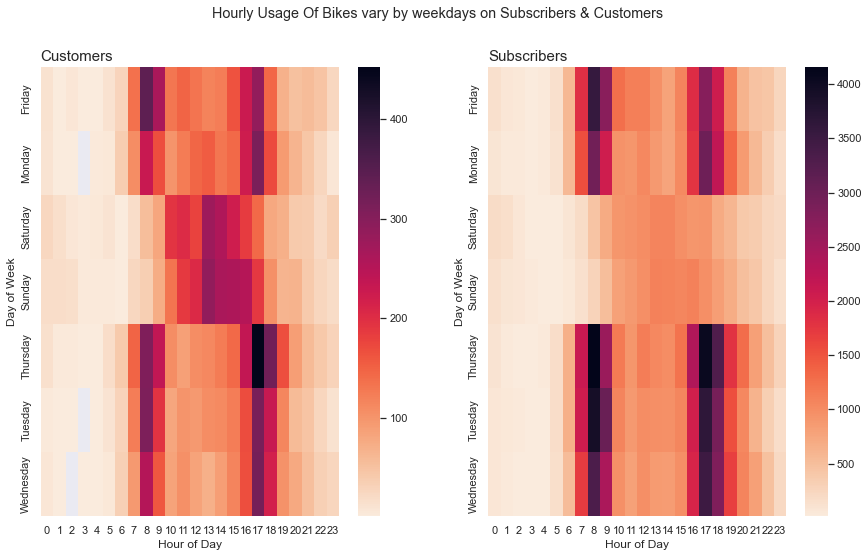

In [6]:
plt.subplot(1, 2, 1)
sb.heatmap(make_counts(customers), cmap='rocket_r')
set_labels("Customers")

plt.subplot(1, 2, 2)
sb.heatmap(make_counts(subscribers), cmap='rocket_r')
set_labels("Subscribers")

plt.suptitle("Hourly Usage Of Bikes vary by weekdays on Subscribers & Customers")

### **✅ User Types & Their Usage**

There is no doubt that the number of subscribers is more than customers. Decreasing the number of subscribers on weekends shows us that they ride bikes only during workdays 💼


Text(0.5, 0.98, 'Daily Usage By Users Type')

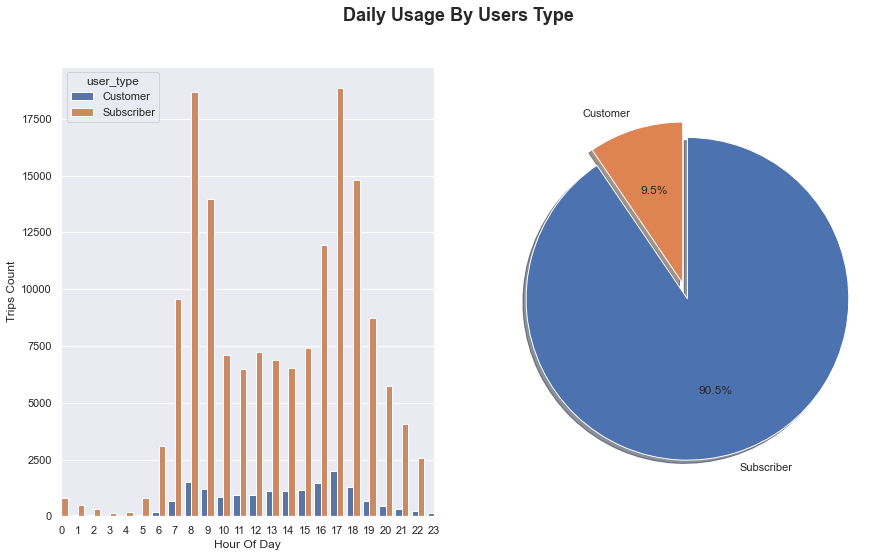

In [7]:

plt.subplot(1, 2, 1)
sb.countplot(data=df, x="start_hour_of_day", hue="user_type")
plt.xlabel("Hour Of Day"), plt.ylabel("Trips Count")
plt.xlim(0, 23)

plt.subplot(1, 2, 2)
sorted_vals = df.user_type.value_counts()/df.shape[0]
plt.pie(sorted_vals, explode=[0, 0.1], labels=sorted_vals.index,
        startangle=90, counterclock=False, autopct='%1.1f%%', shadow=True)
plt.axis('square')


plt.suptitle(
    "Daily Usage By Users Type",
    fontsize=18,
    fontweight="semibold"
)


### **✅ Duration Time Visualization**
Almost all trips were less than 60 min and most of them were between 1 to 20 minutes range. Maximum duration time is ~ 1400 minutes (almost 1 day 🤯)

Text(0.5, 1.0, 'Duration Time Visualization')

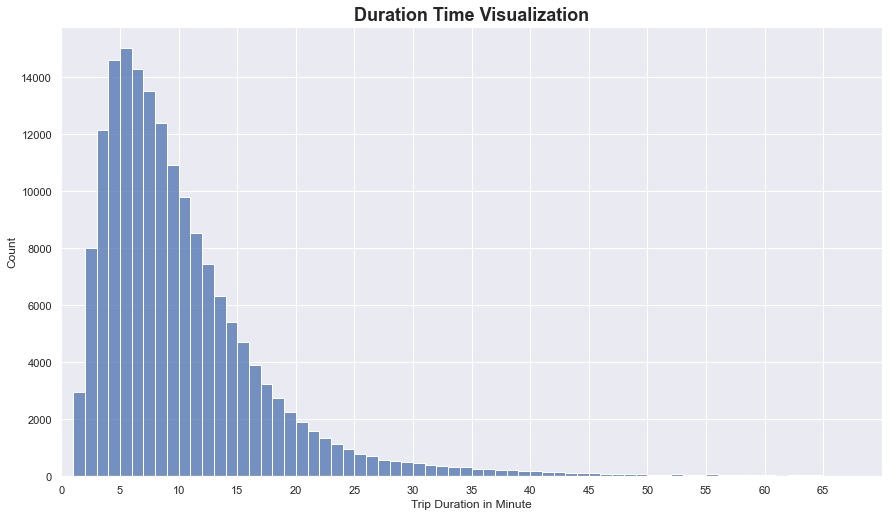

In [8]:
bins,ticks = np.arange(0, 66, 1),np.arange(0, 66, 5)

plt.xticks(ticks, ticks)
plt.xlabel('Trip Duration in Minute')
sb.histplot(data=df,x="duration_min",bins=bins)
plt.xlim(0, 70)
plt.title(
    "Duration Time Visualization",
    fontsize=18,
    fontweight="bold"
)

### **✅ GeoHeatmap of startion station**
To be honest, I don't know this map likes for you or it may not be useful for you.  But after looking dataset, I have brainstormed! I wanted to do something good with locations & prove that locations are also useful for the analysis process.  And, it was a good moment for me to use geodata and create heatmaps according to this on my Jupiter notebook.
We can see that in Oakland, Berkeley and the centre of San Francisco (and near san Francisco's port) were many start stations. But in the below map you can see, there is also another region that was many trips despite its area (San Jose & Japantown).

In [9]:
# Required imports
# You should "trust" to this notebook from FILE panel on your local computer

from folium import Map
from folium.plugins import HeatMap

lat,long = df['start_station_latitude'].mean() , df['start_station_longitude'].mean()

map = Map([lat,long],zoom_start=12)

cords: list = df[
    ['start_station_latitude',
     'start_station_longitude']
].values.tolist()

map.add_child(HeatMap(cords))

map

### **✅ Durations for bikers**

We can see that Customer bikers absolutely ride longer than subscribers. Customers ride longer on weekends & I think it may leisure purpose.

(0.0, 7.0)

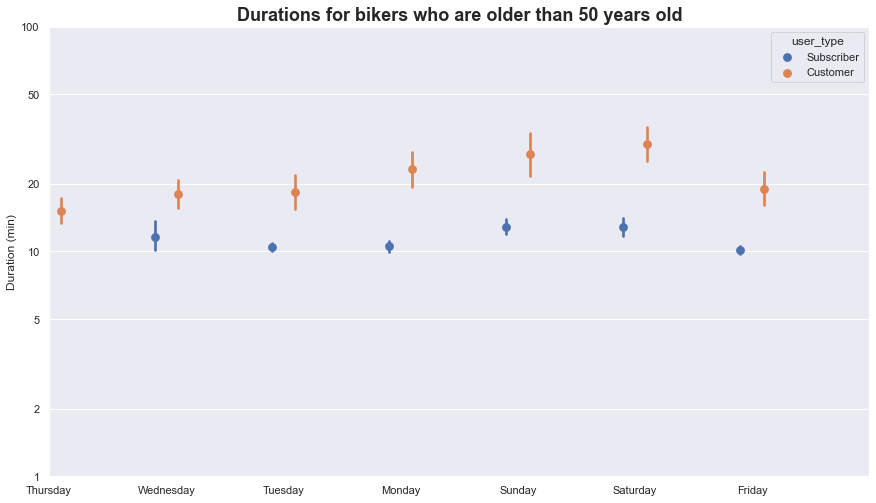

In [10]:
ticks = [1, 2, 5, 10, 20, 50, 100]
users_data: pd.DataFrame = df[df["member_age"] >= 50]

ax = sb.pointplot(
    data=users_data,
    x='start_day_of_week',
    y='duration_min',
    hue='user_type',
    dodge=0.2,
    linestyles=''
)
plt.yscale('log')
plt.ylabel('Duration (min)'),plt.xlabel("Weekday",fontsize=15)
plt.yticks(ticks, ticks)
plt.title(
    'Durations for bikers who are older than 50 years old',
    fontsize=18,
    fontweight="semibold"
)
plt.xlabel('')
plt.xlim(0, 7)

# **🔥 Summary**
Subscribers were shorter trips compared with customers.Most of subscribers used system on their workdays. There was a lot of subscribers than customers on this system. Most of trips were around 8 AM and 17 PM ( afternoon )